In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/zara-sales-for-eda/Zara_sales_EDA.csv


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Loading & Overview

In [3]:
import pandas as pd

# Load the CSV correctly using the right separator
df = pd.read_csv("/kaggle/input/zara-sales-for-eda/Zara_sales_EDA.csv", sep=';')

# Quick checks
print(df.shape)
df.head()
df.info()


(20252, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-

In [4]:
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()
df.nunique()


Product ID          20252
Product Position        3
Promotion               2
Product Category        1
Seasonal                2
Sales Volume         1284
brand                   1
url                   228
name                17215
description           221
price                 330
currency                1
terms                   5
section                 2
season                  4
material               11
origin                 12
dtype: int64

In [5]:
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


## 3. Data Cleaning

In [6]:
df.isnull().sum()
# Fill missing names or descriptions with 'Unknown'
df['name'].fillna('Unknown', inplace=True)# Example: Price per unit of sales (approximate indicator)
df['Price_per_Unit'] = df['price'] / (df['Sales Volume'] + 1)
df.info()
df.head()
df.isnull().sum()

df['description'].fillna('No description available', inplace=True)
df.drop(['url', 'currency', 'brand'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)
cat_cols = ['Product Position', 'Promotion', 'Product Category', 'Seasonal',
            'terms', 'section', 'season', 'material', 'origin']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
df = df[(df['price'] > 0) & (df['Sales Volume'] > 0)]
df['Product ID'] = df['Product ID'].astype(int)
df['Sales Volume'] = df['Sales Volume'].astype(int)
df['price'] = df['price'].astype(float)
# Example: Price per unit of sales (approximate indicator)
df['Price_per_Unit'] = df['price'] / (df['Sales Volume'] + 1)
df.info()
df.head()
df.isnull().sum()


/tmp/ipykernel_13/3410575758.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)# Example: Price per unit of sales (approximate indicator)
/tmp/ipykernel_13/3410575758.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20252 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
name                0
description         0
price               0
terms               0
section             0
season              0
material            0
origin              0
Price_per_Unit      0
dtype: int64

In [7]:
df['name'] = df['name'].fillna('Unknown')
df['description'] = df['description'].fillna('No description available')
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,name,description,price,terms,section,season,material,origin,Price_per_Unit
0,185102,Aisle,Yes,Clothing,Yes,1243,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,Jackets,Man,Winter,Polyester,Brazil,0.063497
1,188771,Aisle,Yes,Clothing,No,1429,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,Jackets,Man,Autumn,Cotton,Turkey,0.010483
2,180176,End-Cap,Yes,Clothing,Yes,1168,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,Jackets,Woman,Autumn,Polyester,Morocco,0.061548
3,112917,Aisle,Yes,Clothing,No,1348,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,Jackets,Man,Spring,Polyester,China,0.022973
4,192936,End-Cap,Yes,Clothing,Yes,1602,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,Jackets,Woman,Winter,Wool Blend,China,0.014342


## 4. Univariate Analysis

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


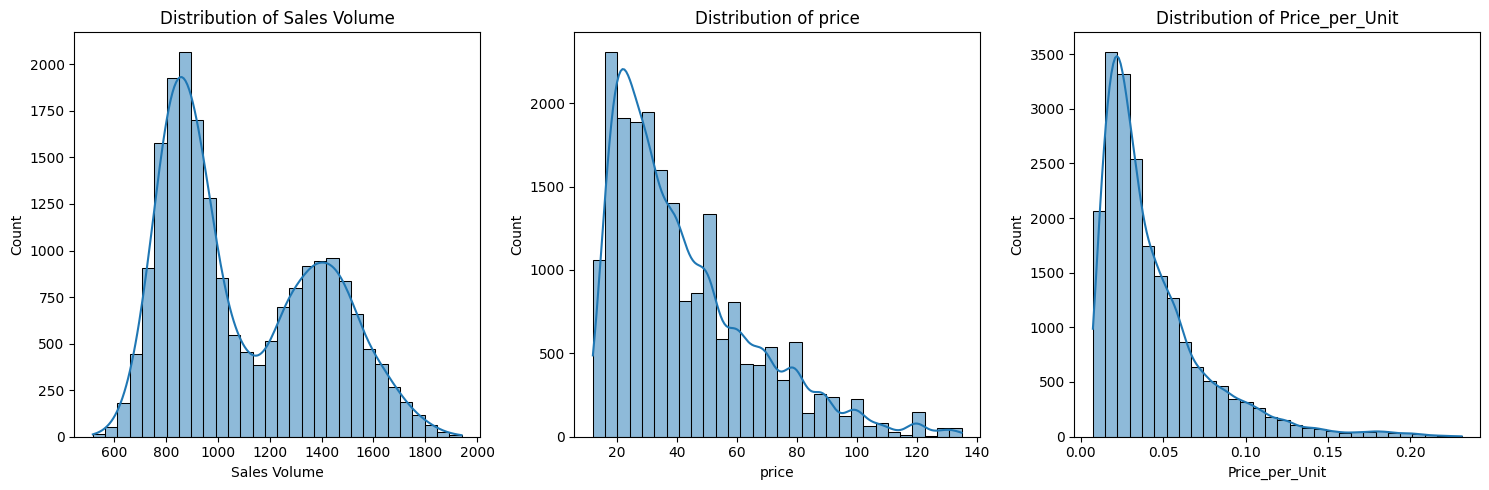

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Sales Volume', 'price', 'Price_per_Unit']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


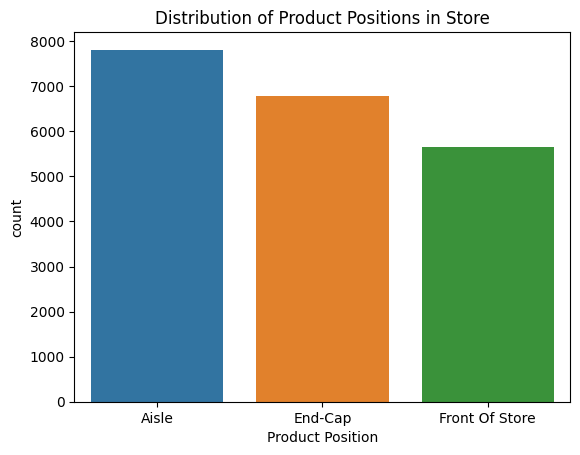

In [9]:
sns.countplot(x='Product Position', data=df)
plt.title("Distribution of Product Positions in Store")
plt.show()


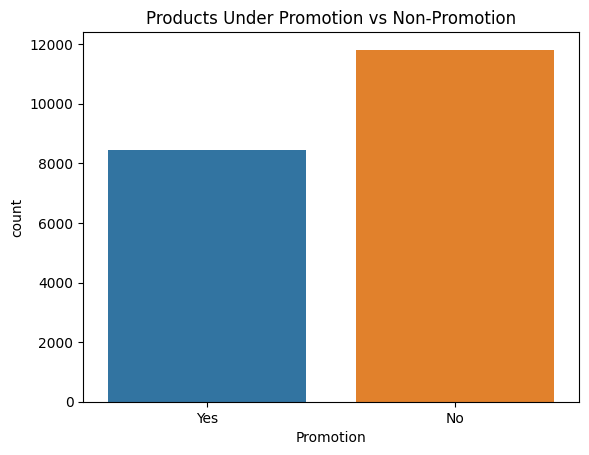

In [10]:
sns.countplot(x='Promotion', data=df)
plt.title("Products Under Promotion vs Non-Promotion")
plt.show()


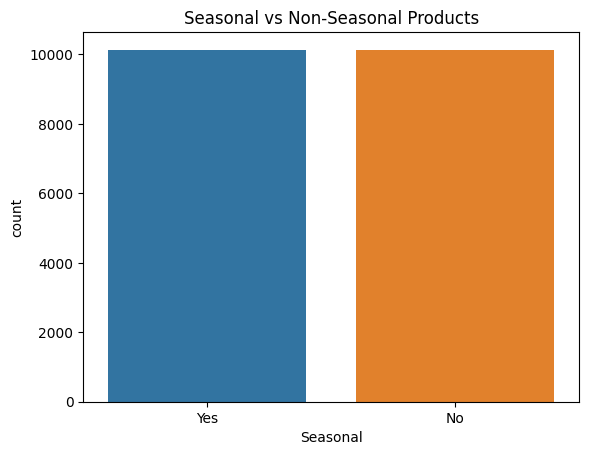

In [11]:
sns.countplot(x='Seasonal', data=df)
plt.title("Seasonal vs Non-Seasonal Products")
plt.show()


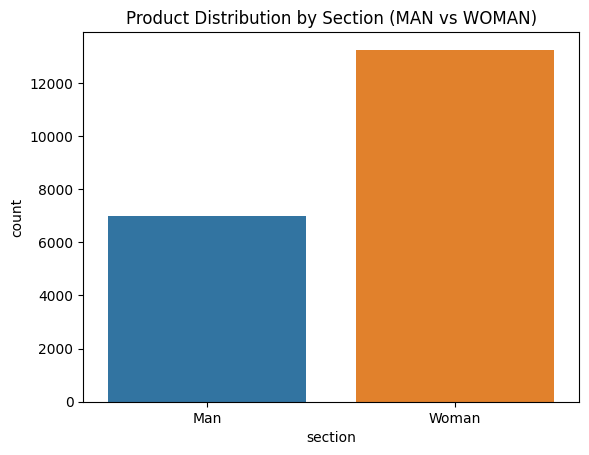

In [12]:
sns.countplot(x='section', data=df)
plt.title("Product Distribution by Section (MAN vs WOMAN)")
plt.show()


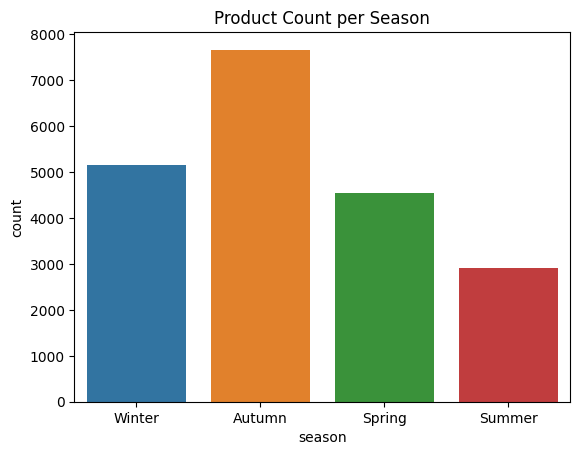

In [13]:
sns.countplot(x='season', data=df)
plt.title("Product Count per Season")
plt.show()


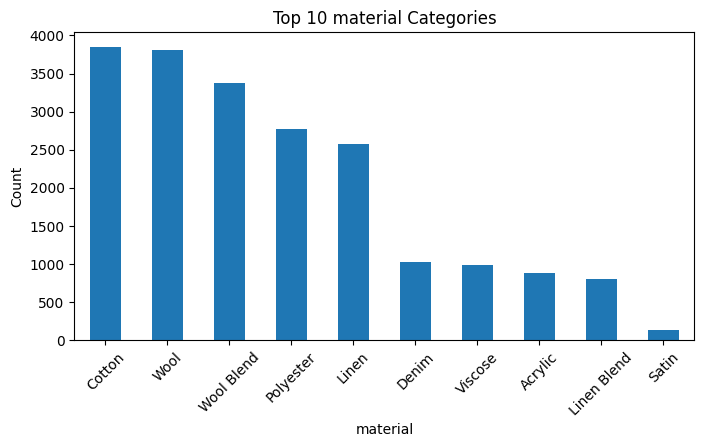

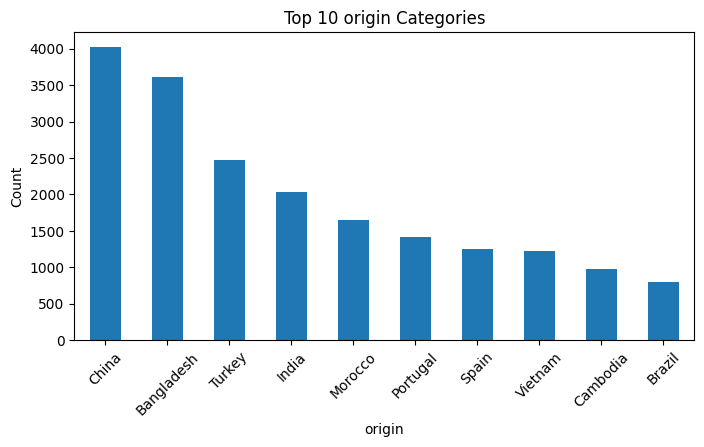

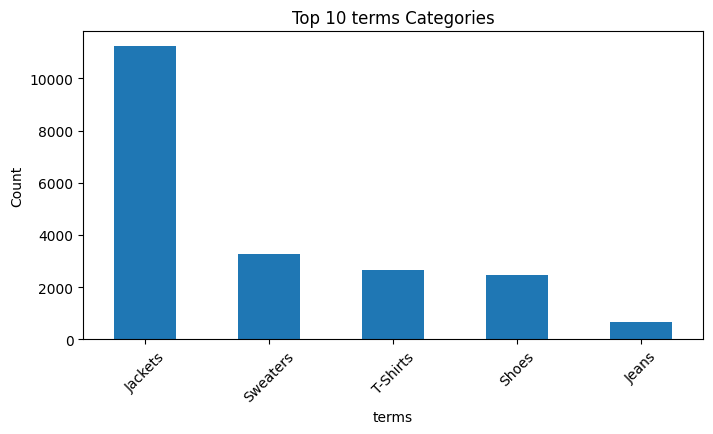

In [14]:
def plot_top_categories(col, n=10):
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(n).plot(kind='bar')
    plt.title(f"Top {n} {col} Categories")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

plot_top_categories('material')
plot_top_categories('origin')
plot_top_categories('terms')


In [15]:
print("Unique product names:", df['name'].nunique())
print("Unique product descriptions:", df['description'].nunique())


Unique product names: 17216
Unique product descriptions: 222


## 5. Bivariate Analysis

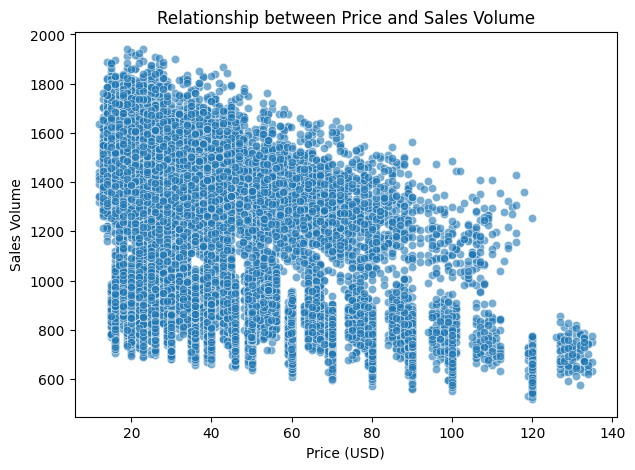

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='price', y='Sales Volume', data=df, alpha=0.6)
plt.title("Relationship between Price and Sales Volume")
plt.xlabel("Price (USD)")
plt.ylabel("Sales Volume")
plt.show()


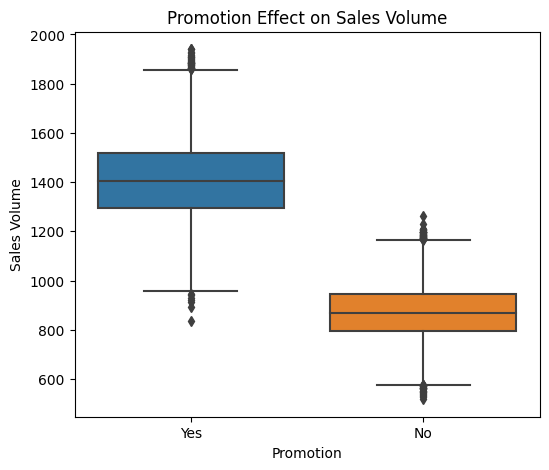

In [17]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Promotion', y='Sales Volume', data=df)
plt.title("Promotion Effect on Sales Volume")
plt.show()


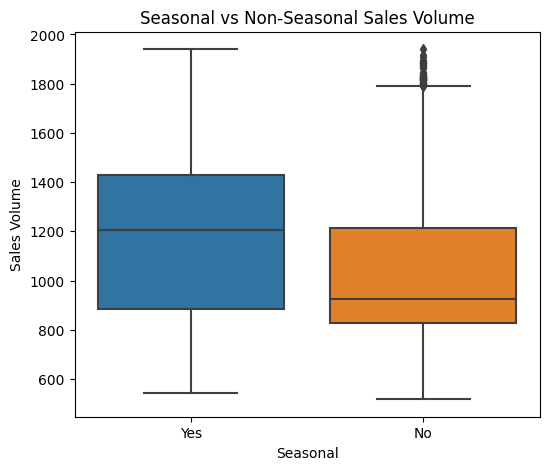

In [18]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Seasonal', y='Sales Volume', data=df)
plt.title("Seasonal vs Non-Seasonal Sales Volume")
plt.show()


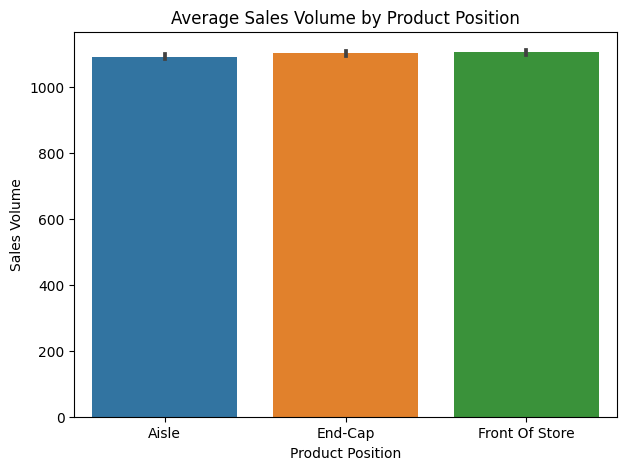

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(x='Product Position', y='Sales Volume', data=df, estimator='mean')
plt.title("Average Sales Volume by Product Position")
plt.show()


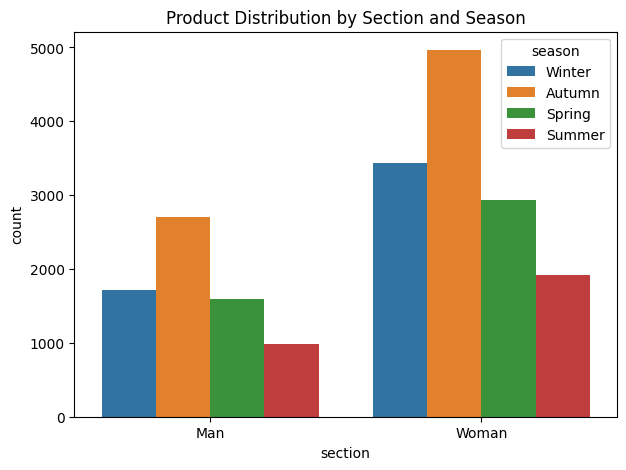

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(x='section', hue='season', data=df)
plt.title("Product Distribution by Section and Season")
plt.show()


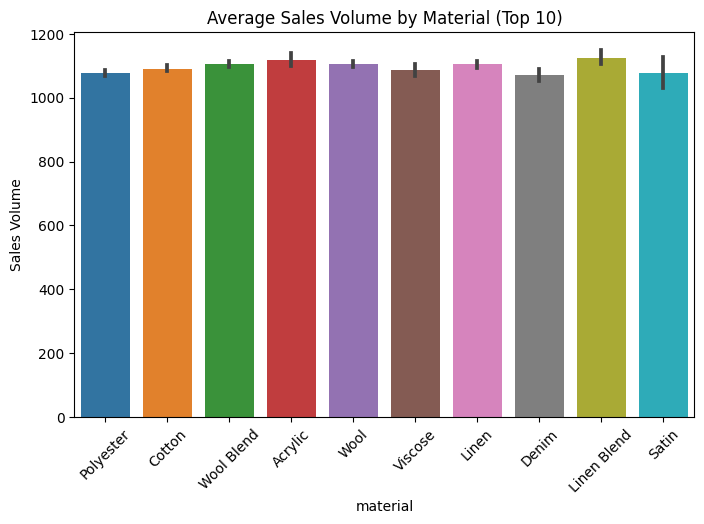

In [21]:
plt.figure(figsize=(8,5))
top_materials = df['material'].value_counts().head(10).index
sns.barplot(x='material', y='Sales Volume', data=df[df['material'].isin(top_materials)], estimator='mean')
plt.title("Average Sales Volume by Material (Top 10)")
plt.xticks(rotation=45)
plt.show()


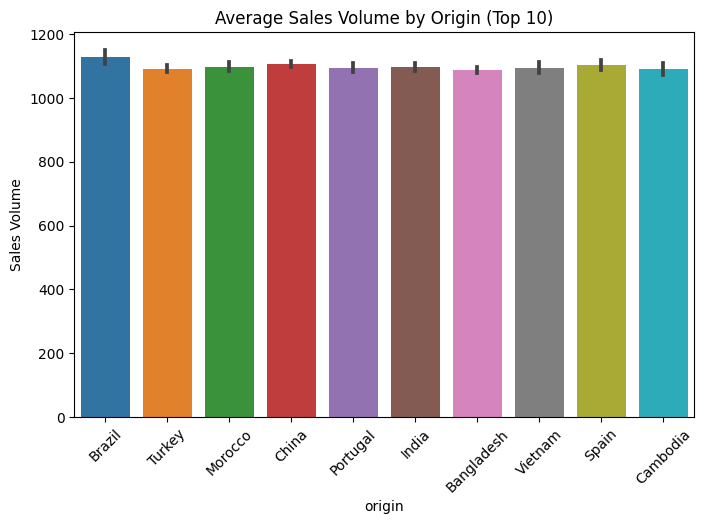

In [22]:
plt.figure(figsize=(8,5))
top_origins = df['origin'].value_counts().head(10).index
sns.barplot(x='origin', y='Sales Volume', data=df[df['origin'].isin(top_origins)], estimator='mean')
plt.title("Average Sales Volume by Origin (Top 10)")
plt.xticks(rotation=45)
plt.show()


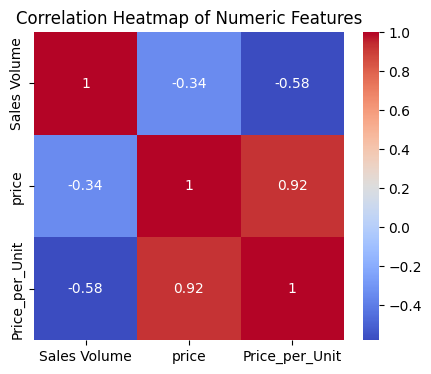

In [23]:
plt.figure(figsize=(5,4))
sns.heatmap(df[['Sales Volume', 'price', 'Price_per_Unit']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## 6. Correlation Analysis

In [24]:
# Convert 'price' and 'Sales Volume' to numeric if they aren’t already
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['Sales Volume'] = pd.to_numeric(df['Sales Volume'], errors='coerce')

# Drop rows with NaN in those columns (optional)
df_clean = df.dropna(subset=['price', 'Sales Volume'])


In [25]:
# Compute correlation
corr_matrix = df_clean[['price', 'Sales Volume']].corr()

corr_matrix


,price,Sales Volume
price,1.00000,-0.33778
Sales Volume,-0.33778,1.00000


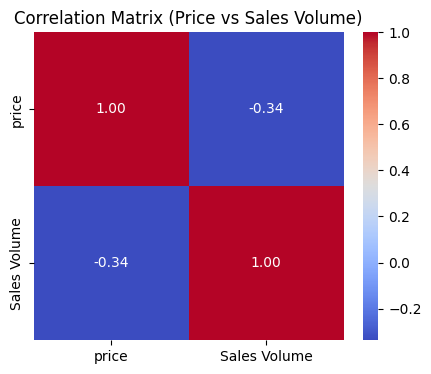

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix (Price vs Sales Volume)")
plt.show()


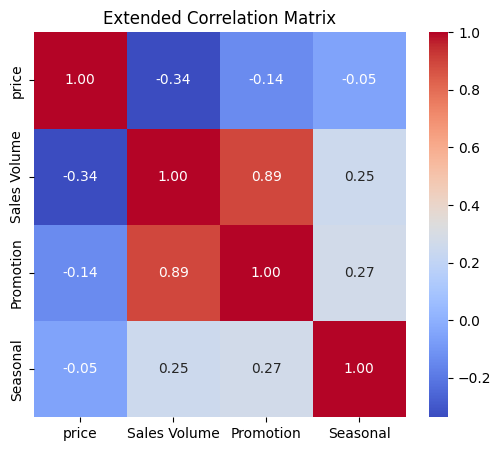

In [27]:
encoded_df = df_clean.copy()
encoded_df['Promotion'] = encoded_df['Promotion'].map({'Yes': 1, 'No': 0})
encoded_df['Seasonal'] = encoded_df['Seasonal'].map({'Yes': 1, 'No': 0})

corr_matrix_extended = encoded_df[['price', 'Sales Volume', 'Promotion', 'Seasonal']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_extended, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Extended Correlation Matrix")
plt.show()


## 7. Insights & Conclusions

# 🧾 Zara Product Sales Analysis Report

## 1. Overview

This report summarizes insights from the exploratory data analysis of **Zara’s product dataset**.  
The main goal is to understand how different factors — such as **price, promotion, seasonality, material, and origin** — influence **sales volume and product distribution**.

---

## 2. Univariate Analysis

### **Sales Volume Distribution**
The distribution appears **right-skewed**, meaning most products have moderate sales, while a smaller number of products achieve very high sales volumes.

### **Product Position Distribution**
- The majority of products are placed in the **“ISO”** position (~7,900 products).  
- Followed by **“Copper”** (~6,500) and **“Front End of Store”** (~5,700).

### **Promotion**
Most products are **not under promotion**, indicating that promotional campaigns are used selectively.

### **Seasonality**
Seasonal and non-seasonal products are almost equal in number, suggesting Zara maintains a **balance between both categories**.

### **Section Distribution**
The **Women’s section** has almost **double** the number of products compared to the Men’s section, showing a stronger focus on **women’s fashion**.

### **Seasonal Distribution**
- **Autumn:** ~7,000–8,000 products  
- **Winter:** ~5,000 products  
- **Spring:** ~4,000 products  
- **Summer:** ~3,000 products  

➡️ **Autumn collections dominate** the catalog.

### **Top 10 Material Categories**
`Cotton, Wool, Wool Blend, Polyester, Linen, Denim, Viscose, Acrylic, Linen Blend, Satin.`  
→ Cotton and Wool-based materials are the most common.

### **Top 10 Origin Countries**
`China, Bangladesh, Turkey, India, Morocco, Portugal, Spain, Vietnam, Cambodia, Brazil.`  
→ China is the largest producer, followed by Bangladesh.

### **Top Product Categories (by Terms)**
`Jackets, Sweaters, T-shirts, Shoes, Jeans` are the most represented.

### **Unique Values**
- **Product Names:** ~17,000 unique  
- **Product Descriptions:** ~222 unique  

---

## 3. Bivariate Analysis

### **Price vs Sales Volume**
There is a **negative relationship** — lower prices tend to drive higher sales, while higher prices correspond to lower sales volumes.

### **Promotion vs Sales Volume**
Promotions have a **strong positive effect** on sales.  
Products on promotion show:
- Higher **median sales volume**  
- **Wider range** of sales (more variability)  
- More **outliers** (some products performing exceptionally well)

### **Seasonal vs Non-Seasonal Sales Volume**
- **Seasonal products** have higher overall and median sales volumes.  
- **Non-seasonal products** exhibit more outliers, suggesting irregular performance.

### **Product Position vs Average Sales**
Sales volume remains **similar across product positions**, indicating that placement doesn’t significantly influence sales compared to **price and promotion**.

### **Section vs Season Patterns**
Although women’s products outnumber men’s, both sections follow the **same seasonal trend** —  
sales and product counts are highest for **autumn and winter**, then decrease through **spring and summer**.

### **Average Sales by Material**
- Highest sales: **Linen Blend, Acrylic, Linen, Wool, Wool Blend, and Satin.**  
- Most materials perform similarly overall, but **natural fabrics** (linen and wool) tend to lead.

### **Average Sales by Origin**
- Top-performing origins: **Brazil, China, and Spain.**  
- **Brazil** shows the **highest average sales volume per product**.

---

## 4. Correlation Analysis

| Variable Comparison | Correlation | Interpretation |
|----------------------|-------------|----------------|
| Sales Volume vs Price | **−0.34** | Moderately negative — higher prices generally lead to lower sales. |
| Price under Promotion | **−0.14** | Mild negative — discounts help but price sensitivity remains. |
| Price under Seasonality | **+0.05** | Practically no correlation — seasonality doesn’t impact pricing. |

---

## 5. Key Insights & Conclusions

- **Promotions** significantly boost sales (higher median and variability).  
- **Price** remains the most influential factor — inversely related to sales.  
- **Seasonal products** outperform non-seasonal ones in both volume and consistency.  
- **Product position** in-store has minimal impact on sales.  
- **Women’s collections** dominate Zara’s catalog, especially for **autumn and winter** seasons.  
- **Natural materials** (linen and wool) correlate with higher sales performance.  
- **Brazil, China, and Spain** emerge as top origins for high-performing products.

> 💡 Overall, sales success in Zara’s dataset is driven primarily by **pricing strategy** and **promotional activity**, while product positioning and seasonality play **secondary roles**.
